## Select stories from Narratives dataset for data analysis 

In [1]:
import os
import pandas as pd
import json

In [2]:
Dir_project = '/work/desai-lab/xuanyang/Project/dataset/Nastase/narratives'
f = open(os.path.join(Dir_project,'code','scan_exclude.json'))
df_scan_exclude = []
dict_scan_exclude = json.load(f)
for task in dict_scan_exclude:
    if len(dict_scan_exclude[task])!=0:
        for subID in dict_scan_exclude[task]:
            df_tmp = pd.DataFrame({'subID':subID,'task':task},index=[0])
            df_scan_exclude.append(df_tmp)
df_scan_exclude = pd.concat(df_scan_exclude,ignore_index=True)
mastersheetFile = '/work/desai-lab/xuanyang/Project/dataset/Nastase/Participants.xlsx'
df_participant = pd.read_excel(mastersheetFile)
df_master = pd.DataFrame()
n=0
for i in range(len(df_participant)):
    df_master_i = df_participant.loc[i]
    if len(df_master_i.task.split(','))>1:
        for j in range(len(df_master_i.task.split(','))):
            df_master.loc[n,'subID'] = df_master_i.participant_id
            df_master.loc[n,'task'] = df_master_i.task.split(',')[j]
            df_master.loc[n,'age'] = df_master_i.age.split(',')[j]
            df_master.loc[n,'sex'] = df_master_i.sex.split(',')[j]
            df_master.loc[n,'condition'] = df_master_i.condition.split(',')[j]
            df_master.loc[n,'comprehension'] = df_master_i.comprehension.split(',')[j]
            if not any((df_scan_exclude.task == df_master.loc[n,'task']) & (df_scan_exclude.subID == df_master.loc[n,'subID'])):
                n=n+1
    else:
        df_master.loc[n] = df_master_i
df_master

,subID,task,age,sex,condition,comprehension
0,sub-001,tunnel,23,F,n/a,n/a
1,sub-004,pieman,24,M,n/a,n/a
2,sub-005,pieman,n/a,M,n/a,n/a
3,sub-005,tunnel,n/a,M,n/a,n/a
4,sub-016,pieman,n/a,F,n/a,n/a
...,...,...,...,...,...,...
636,sub-343,notthefallshortscram,18,F,intact-shortscram,n/a
637,sub-344,notthefallintact,18,F,intact-longscram,n/a
638,sub-344,notthefalllongscram,18,F,intact-longscram,n/a
639,sub-345,notthefallintact,18,F,intact-shortscram,n/a


In [13]:
List_task_exclude = ['shapesphysical','merlin','sherlock']
f = open(os.path.join(Dir_project,'code','event_meta.json'))
df_event_meta = []
dict_event_meta = json.load(f)
for story1 in dict_event_meta:
    if story1=='slumlordreach':
        for story2 in ['slumlord','reach']:
            df_tmp = pd.DataFrame(dict_event_meta[story1][story2],index=[0])
            df_tmp['task'] = story1
            df_tmp['story'] = story2
            df_event_meta.append(df_tmp)
    else:
        story2 = story1
        df_tmp = pd.DataFrame(dict_event_meta[story1][story2],index=[0])
        df_tmp['task'] = story1
        df_tmp['story'] = story2
        df_event_meta.append(df_tmp)
df_event_meta = pd.concat(df_event_meta,ignore_index=True)
for i,task in enumerate(df_event_meta.task):
    df_event_meta.loc[i,'Nsubj'] = len(df_master.loc[df_master.task==task])
    if task in df_master.loc[df_master.comprehension!='n/a','task'].unique():
        df_event_meta.loc[i,'comprehension'] = 1
    else:
        df_event_meta.loc[i,'comprehension'] = 0
    df_event_meta.loc[i,'duration_min'] = df_event_meta.loc[i,'duration']*1.5/60
df_event_meta_filter = df_event_meta.loc[(~df_event_meta.task.isin(List_task_exclude))&(df_event_meta.comprehension==1)]
df_event_meta_filter.to_csv('/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/scripts/fMRI/master_event_10stories_highacc.csv')
df_event_meta_filter


,duration,onset,task,story,Nsubj,comprehension,duration_min
0,2225,14,21styear,21styear,10.0,1.0,55.625
1,533,8,black,black,47.0,1.0,13.325
2,357,8,bronx,bronx,47.0,1.0,8.925
3,558,8,forgot,forgot,47.0,1.0,13.950
6,269,14,milkyway,milkyway,34.0,1.0,6.725
11,267,8,piemanpni,piemanpni,47.0,1.0,6.675
12,451,14,prettymouth,prettymouth,35.0,1.0,11.275
14,272,33,shapessocial,shapessocial,58.0,1.0,6.800
16,602,20,slumlordreach,slumlord,16.0,1.0,15.050
17,550,646,slumlordreach,reach,16.0,1.0,13.750


In [4]:
df_master_filter = df_master.loc[(~df_master.task.isin(List_task_exclude))&(df_master.comprehension!='n/a')].copy()
df_master_filter['comprehension'] = df_master_filter.comprehension.astype(float)
df_master_filter.loc[df_master_filter.task=='shapessocial','comprehension'] = df_master_filter.loc[df_master_filter.task=='shapessocial','comprehension']/10
df_master_filter_highacc = df_master_filter.loc[df_master_filter.comprehension>=.6].copy()
df_master_filter_highacc

,subID,task,age,sex,condition,comprehension
11,sub-023,prettymouth,28,F,affair,0.889
12,sub-023,milkyway,28,F,vodka,1.000
19,sub-030,prettymouth,21,F,paranoia,0.963
20,sub-030,milkyway,21,F,vodka,0.893
22,sub-032,prettymouth,22,M,affair,0.963
...,...,...,...,...,...,...
592,sub-314,piemanpni,25,F,n/a,0.767
593,sub-314,bronx,25,F,n/a,0.780
594,sub-314,forgot,25,F,n/a,0.780
595,sub-314,black,25,F,n/a,0.920


In [12]:
Dir_gentle = '/work/desai-lab/xuanyang/Project/dataset/Nastase/narratives/stimuli/gentle/'
for i,subID,task,condition in zip(df_master_filter_highacc.index,df_master_filter_highacc.subID,df_master_filter_highacc.task,df_master_filter_highacc.condition):
    if task !='milkyway':
        df_master_filter_highacc.loc[i,'transcript'] = task
        path_timestamps = os.path.join(Dir_gentle,task,'align.csv')
        if not os.path.exists(path_timestamps):
            
            print(subID,task)
    else: 
        df_master_filter_highacc.loc[i,'transcript'] = task+condition
        path_timestamps = os.path.join(Dir_gentle,task+condition,'align.csv')
        if not os.path.exists(path_timestamps):
            
            print(subID,task,condition)

# sub-280, task-piemanpni is missing from the Narratives dataset
df_master_filter_highacc = df_master_filter_highacc.loc[~((df_master_filter_highacc.subID=='sub-280')&(df_master_filter_highacc.task=='piemanpni'))].reset_index(drop=True)

for i,subID,task,condition in zip(df_master_filter_highacc.index,df_master_filter_highacc.subID,df_master_filter_highacc.task,df_master_filter_highacc.condition):
    if (condition == 'n/a')|(task=='prettymouth')|(task=='shapessocial'):
        df_master_filter_highacc.loc[i,'label'] = task
    else:
        df_master_filter_highacc.loc[i,'label'] = task+condition

df_master_filter_highacc.to_csv('/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/scripts/fMRI/master_subject_10stories_highacc.csv',index=False)
df_master_filter_highacc
print(len(df_master_filter_highacc.subID.unique()))

,subID,task,age,sex,condition,comprehension,transcript,label
0,sub-023,prettymouth,28,F,affair,0.889,prettymouth,prettymouth
1,sub-023,milkyway,28,F,vodka,1.000,milkywayvodka,milkywayvodka
2,sub-030,prettymouth,21,F,paranoia,0.963,prettymouth,prettymouth
3,sub-030,milkyway,21,F,vodka,0.893,milkywayvodka,milkywayvodka
4,sub-032,prettymouth,22,M,affair,0.963,prettymouth,prettymouth
...,...,...,...,...,...,...,...,...
208,sub-314,piemanpni,25,F,n/a,0.767,piemanpni,piemanpni
209,sub-314,bronx,25,F,n/a,0.780,bronx,bronx
210,sub-314,forgot,25,F,n/a,0.780,forgot,forgot
211,sub-314,black,25,F,n/a,0.920,black,black


<Axes: xlabel='comprehension', ylabel='Count'>

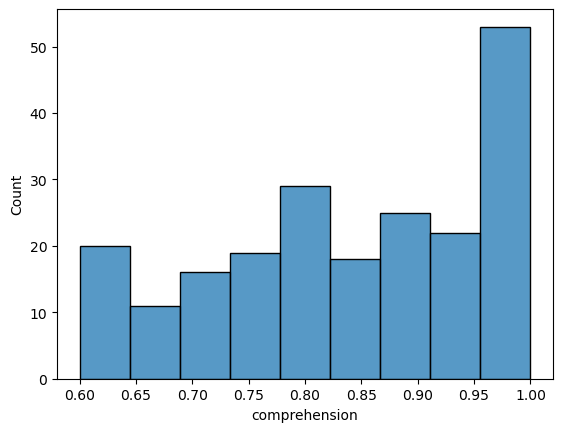

In [10]:
import seaborn as sns
sns.histplot(x='comprehension',data=df_master_filter_highacc)

## Organize the timestamps from the selected stories

In [14]:
import nltk
import pandas as pd

Dir_gentle = '/work/desai-lab/xuanyang/Project/dataset/Nastase/narratives/stimuli/gentle/'
df_event_meta_filter = pd.read_csv('/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/scripts/fMRI/master_event_10stories_highacc.csv')
df_master_filter_highacc = pd.read_csv('/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/scripts/fMRI/master_subject_10stories_highacc.csv')
df_timestamps = []
for label in df_master_filter_highacc.label.unique():
    path_timestamps = os.path.join(Dir_gentle,label,'align.csv')
    df_tmp = pd.read_csv(path_timestamps,header=None)
    df_tmp.columns = ['word','word_detected','onset','offset']
    df_tmp['story_audio'] = label
    
    
    tagged_tokens = nltk.pos_tag(df_tmp.word)
    df = pd.DataFrame(tagged_tokens, columns=['Word', 'PoS'])
    df_tmp['PoS'] = df['PoS']
    
    
    df_timestamps.append(df_tmp)
df_timestamps = pd.concat(df_timestamps,ignore_index=True)
df_timestamps.to_csv('/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/scripts/fMRI/Timestamps_10stories.csv',index=False)
df_timestamps

,word,word_detected,onset,offset,story_audio,PoS
0,When,when,1.340000,1.500000,prettymouth,WRB
1,the,the,21.150000,21.250000,prettymouth,DT
2,phone,phone,21.250000,21.560000,prettymouth,NN
3,rang,rang,21.560000,21.990000,prettymouth,VBD
4,the,the,22.070000,22.190000,prettymouth,DT
...,...,...,...,...,...,...
24653,C,c,818.280000,818.710000,forgot,NNP
24654,D,d,819.809999,820.159999,forgot,NNP
24655,E,e,821.540000,821.880000,forgot,NNP
24656,F,f,822.969999,823.429999,forgot,NNP


### Download fmri data

In [46]:
import datalad.api as dl
Dir_derivatives = os.path.join(Dir_project,'derivatives')

for subID,task in zip(df_master_filter.subID,df_master_filter.task):
    if (subID=='sub-280')&(task=='piemanpni'):
        continue
    else:
        # confounding
        Dir_sub = os.path.join(Dir_derivatives,'afni-smooth',subID)
        file_confounding = '{}_task-{}_desc-model_regressors.csv'.format(subID,task)
        path_file_confounding = os.path.join(Dir_sub,'func',file_confounding)
        if not os.path.exists(path_file_confounding):
            os.chdir(Dir_sub)
            dl.get(path_file_confounding)

        # clean
        if task in ['shapessocial','black','bronx','forgot','piemanpni']:
            label = 'afni-nosmooth'
            Dir_sub = os.path.join(Dir_derivatives,label,subID)
            img_clean = '{}_task-{}_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz'.format(subID,task)
            path_img_clean = os.path.join(Dir_sub,'func',img_clean)
            if not os.path.exists(path_img_clean):
                os.chdir(Dir_sub)
                dl.get(path_img_clean)
        else:
            for label in ['afni-nosmooth','afni-smooth']:
                Dir_sub = os.path.join(Dir_derivatives,label,subID)
                img_clean = '{}_task-{}_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz'.format(subID,task)
                path_img_clean = os.path.join(Dir_sub,'func',img_clean)
                if not os.path.exists(path_img_clean):
                    os.chdir(Dir_sub)
                    dl.get(path_img_clean)


        # brain mask
        
        Dir_sub = os.path.join(Dir_derivatives,'fmriprep',subID)
        
        img_mask = '{}_task-{}_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz'.format(subID,task)
        path_img_mask = os.path.join(Dir_sub,'func',img_mask)
        if not os.path.exists(path_img_mask):
            os.chdir(Dir_sub)
            dl.get(path_img_mask)
        

get(ok): sub-023/func/sub-023_task-prettymouth_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-023/func/sub-023_task-prettymouth_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-023/func/sub-023_task-prettymouth_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-023/func/sub-023_task-milkyway_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-023/func/sub-023_task-milkyway_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-023/func/sub-023_task-milkyway_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-030/func/sub-030_task-prettymouth_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-030/func/sub-030_task-prettymouth_space-MNI152NLin2009cAsym_res-n

get(ok): sub-098/func/sub-098_task-prettymouth_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-098/func/sub-098_task-prettymouth_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-098/func/sub-098_task-prettymouth_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-098/func/sub-098_task-milkyway_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-098/func/sub-098_task-milkyway_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-098/func/sub-098_task-milkyway_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-099/func/sub-099_task-prettymouth_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-099/func/sub-099_task-prettymouth_space-MNI152NLin2009cAsym_res-n

get(ok): sub-265/func/sub-265_task-21styear_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-265/func/sub-265_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-265/func/sub-265_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-265/func/sub-265_task-bronx_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-265/func/sub-265_task-bronx_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-265/func/sub-265_task-forgot_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-265/func/sub-265_task-black_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-267/func/sub-267_task-21styear_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.ni

get(ok): sub-291/func/sub-291_task-bronx_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-291/func/sub-291_task-forgot_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-291/func/sub-291_task-black_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-292/func/sub-292_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-292/func/sub-292_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-292/func/sub-292_task-bronx_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-292/func/sub-292_task-bronx_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-292/func/sub-292_task-forgot_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz 

get(ok): sub-312/func/sub-312_task-bronx_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-312/func/sub-312_task-forgot_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-312/func/sub-312_task-black_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-313/func/sub-313_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-313/func/sub-313_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-313/func/sub-313_task-bronx_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
get(ok): sub-313/func/sub-313_task-bronx_space-MNI152NLin2009cAsym_res-native_desc-brain_mask.nii.gz (file) [from fcp-indi...]
get(ok): sub-313/func/sub-313_task-forgot_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz 

### Check if everything is downloaded

In [15]:
import os
import pandas as pd
path_df_master_filter_highacc = '/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/scripts/fMRI/master_subject_10stories_highacc.csv'
df_master_filter_highacc = pd.read_csv(path_df_master_filter_highacc)
df_master_filter_highacc

,subID,task,age,sex,condition,comprehension,transcript,label
0,sub-023,prettymouth,28,F,affair,0.889,prettymouth,prettymouth
1,sub-023,milkyway,28,F,vodka,1.000,milkywayvodka,milkywayvodka
2,sub-030,prettymouth,21,F,paranoia,0.963,prettymouth,prettymouth
3,sub-030,milkyway,21,F,vodka,0.893,milkywayvodka,milkywayvodka
4,sub-032,prettymouth,22,M,affair,0.963,prettymouth,prettymouth
...,...,...,...,...,...,...,...,...
208,sub-314,piemanpni,25,F,NaN,0.767,piemanpni,piemanpni
209,sub-314,bronx,25,F,NaN,0.780,bronx,bronx
210,sub-314,forgot,25,F,NaN,0.780,forgot,forgot
211,sub-314,black,25,F,NaN,0.920,black,black


In [36]:
import datalad.api as dl
Dir_derivatives = '/work/desai-lab/xuanyang/Project/dataset/Nastase/narratives/derivatives/'
Dir_smooth = os.path.join(Dir_derivatives,'afni-smooth')
Dir_nosmooth = os.path.join(Dir_derivatives,'afni-nosmooth')

for i,subID,task in zip(df_master_filter_highacc.index,df_master_filter_highacc.subID,df_master_filter_highacc.task):
    
    # confounding
    df_master_filter_highacc.loc[i,'confounding'] = os.path.join(Dir_derivatives,'fmriprep',subID,'func','{}_task-{}_desc-confounds_regressors.tsv'.format(subID,task))
    if not os.path.exists(df_master_filter_highacc.loc[i,'confounding']):
        os.chdir(os.path.join(Dir_derivatives,'fmriprep',subID,'func'))
        dl.get(df_master_filter_highacc.loc[i,'confounding'])
        print(subID,task)
    # reslice
    
    
    # smooth
    df_master_filter_highacc.loc[i,'smooth_clean'] = os.path.join(Dir_derivatives,'afni-smooth',subID,'func','{}_task-{}_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz'.format(subID,task))
    if not os.path.exists(df_master_filter_highacc.loc[i,'smooth_clean']):
        if task not in ['black','forgot']:
            os.chdir(os.path.join(Dir_derivatives,'afni-smooth',subID,'func'))
            dl.get(df_master_filter_highacc.loc[i,'smooth_clean'])
            print('no file: smooth',subID,task)
            
    # nosmooth
    df_master_filter_highacc.loc[i,'nosmooth_clean'] = os.path.join(Dir_derivatives,'afni-nosmooth',subID,'func','{}_task-{}_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz'.format(subID,task))
    if not os.path.exists(df_master_filter_highacc.loc[i,'nosmooth_clean']):
        if task not in ['black','forgot']:
            os.chdir(os.path.join(Dir_derivatives,'afni-nosmooth',subID,'func'))
            dl.get(df_master_filter_highacc.loc[i,'nosmooth_clean'])
            print('no file: nosmooth',subID,task)
    
    # event

get(ok): sub-127/func/sub-127_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
no file: smooth sub-127 piemanpni
get(ok): sub-265/func/sub-265_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
no file: smooth sub-265 piemanpni
get(ok): sub-267/func/sub-267_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
no file: smooth sub-267 piemanpni
get(ok): sub-273/func/sub-273_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
no file: smooth sub-273 piemanpni
get(ok): sub-274/func/sub-274_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
no file: smooth sub-274 piemanpni
get(ok): sub-275/func/sub-275_task-piemanpni_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz (file) [from fcp-indi...]
no file: smooth sub-275 piemanpni
get(ok): s

In [39]:
### Reslice

from subprocess import run

img_tpl = '/work/desai-lab/xuanyang/Project/dataset/Nastase/narratives/derivatives/afni-smooth/sub-023/func/sub-023_task-milkyway_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz'
Dir_mask = os.path.join(Dir_smooth,'tpl-MNI152NLin2009cAsym')
for i,subID,task in zip(df_master_filter_highacc.index,df_master_filter_highacc.subID,df_master_filter_highacc.task):
    if task in ['shapessocial','black','bronx','forgot','piemanpni']:
        df_master_filter_highacc.loc[i,'smooth_clean_rs'] = os.path.join(Dir_derivatives,'afni-smooth',subID,'func','rs_{}_task-{}_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz'.format(subID,task))
        maskFile_in = df_master_filter_highacc.loc[i,'smooth_clean']
        maskFile_out = df_master_filter_highacc.loc[i,'smooth_clean_rs']
        if not os.path.exists(maskFile_out):
            run(f"/work/apps/AFNI/linux_openmp_64/3dresample -master {img_tpl} -prefix {maskFile_out} -input {maskFile_in}",shell=True)
        
        df_master_filter_highacc.loc[i,'nosmooth_clean_rs'] = os.path.join(Dir_derivatives,'afni-nosmooth',subID,'func','rs_{}_task-{}_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz'.format(subID,task))
        maskFile_in = df_master_filter_highacc.loc[i,'nosmooth_clean']
        maskFile_out = df_master_filter_highacc.loc[i,'nosmooth_clean_rs']
        if not os.path.exists(maskFile_out):
            run(f"/work/apps/AFNI/linux_openmp_64/3dresample -master {img_tpl} -prefix {maskFile_out} -input {maskFile_in}",shell=True)
       

/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_

/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_openmp_64/3dresample: /work/apps/python3/anaconda/2021.11/lib/libuuid.so.1: no version information available (required by /lib64/libSM.so.6)
/work/apps/AFNI/linux_

In [49]:
### Reslice

from subprocess import run

img_tpl = '/work/desai-lab/xuanyang/Project/dataset/Nastase/narratives/derivatives/afni-smooth/sub-023/func/sub-023_task-milkyway_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz'
Dir_mask = os.path.join(Dir_smooth,'tpl-MNI152NLin2009cAsym')
for i,subID,task in zip(df_master_filter_highacc.index,df_master_filter_highacc.subID,df_master_filter_highacc.task):
    if task in ['shapessocial','black','bronx','forgot','piemanpni']:
        df_master_filter_highacc.loc[i,'smooth_clean_rs'] = os.path.join(Dir_derivatives,'afni-smooth',subID,'func','rs_{}_task-{}_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz'.format(subID,task))
        maskFile_in = df_master_filter_highacc.loc[i,'smooth_clean']
        maskFile_out = df_master_filter_highacc.loc[i,'smooth_clean_rs']
        if not os.path.exists(maskFile_out):
            run(f"/work/apps/AFNI/linux_openmp_64/3dresample -master {img_tpl} -prefix {maskFile_out} -input {maskFile_in}",shell=True)
        
        df_master_filter_highacc.loc[i,'nosmooth_clean_rs'] = os.path.join(Dir_derivatives,'afni-nosmooth',subID,'func','rs_{}_task-{}_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz'.format(subID,task))
        maskFile_in = df_master_filter_highacc.loc[i,'nosmooth_clean']
        maskFile_out = df_master_filter_highacc.loc[i,'nosmooth_clean_rs']
        if not os.path.exists(maskFile_out):
            run(f"/work/apps/AFNI/linux_openmp_64/3dresample -master {img_tpl} -prefix {maskFile_out} -input {maskFile_in}",shell=True)
    else:
        df_master_filter_highacc.loc[i,'smooth_clean_rs'] = df_master_filter_highacc.loc[i,'smooth_clean']
        df_master_filter_highacc.loc[i,'nosmooth_clean_rs'] = df_master_filter_highacc.loc[i,'nosmooth_clean']
df_master_filter_highacc.to_csv('/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/master/codes/master_subject_10stories_highacc.csv',index=False)
df_master_filter_highacc

,subID,task,age,sex,condition,comprehension,transcript,label,confounding,smooth_clean,nosmooth_clean,smooth_clean_rs,nosmooth_clean_rs
0,sub-023,prettymouth,28,F,affair,0.889,prettymouth,prettymouth,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...
1,sub-023,milkyway,28,F,vodka,1.000,milkywayvodka,milkywayvodka,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...
2,sub-030,prettymouth,21,F,paranoia,0.963,prettymouth,prettymouth,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...
3,sub-030,milkyway,21,F,vodka,0.893,milkywayvodka,milkywayvodka,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...
4,sub-032,prettymouth,22,M,affair,0.963,prettymouth,prettymouth,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,sub-314,piemanpni,25,F,NaN,0.767,piemanpni,piemanpni,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...
209,sub-314,bronx,25,F,NaN,0.780,bronx,bronx,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...
210,sub-314,forgot,25,F,NaN,0.780,forgot,forgot,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...
211,sub-314,black,25,F,NaN,0.920,black,black,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...,/work/desai-lab/xuanyang/Project/dataset/Nasta...


In [60]:

df_master_filter_highacc = pd.read_csv('/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/master/codes/master_subject_10stories_highacc.csv')
for i,subID,task in zip(df_master_filter_highacc.index,df_master_filter_highacc.subID,df_master_filter_highacc.task):
    df_master_filter_highacc.loc[i,'event'] = os.path.join('/work/desai-lab/xuanyang/Project/dataset/Nastase/narratives',subID,'func','{}_task-{}_events.tsv'.format(subID,task))
    if not os.path.exists(df_master_filter_highacc.loc[i,'event']):
        print('no event:',subID,task)
    df_event = pd.read_csv(df_master_filter_highacc.loc[i,'event'])
    if len(df_event) == 0:
        print('no event:',subID,task)
df_master_filter_highacc.to_csv('/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/master/codes/master_subject_10stories_highacc.csv',index=False)

### Scope dataset

In [16]:
import pandas as pd
import os
df_timestamps = pd.read_csv('/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI/scripts/fMRI/Timestamps_10stories.csv')
df_timestamps['word_lower'] = df_timestamps['word'].str.lower()
df_timestamps['idx'] = range(len(df_timestamps))
df_timestamps


,word,word_detected,onset,offset,story_audio,PoS,word_lower,idx
0,When,when,1.340000,1.500000,prettymouth,WRB,when,0
1,the,the,21.150000,21.250000,prettymouth,DT,the,1
2,phone,phone,21.250000,21.560000,prettymouth,NN,phone,2
3,rang,rang,21.560000,21.990000,prettymouth,VBD,rang,3
4,the,the,22.070000,22.190000,prettymouth,DT,the,4
...,...,...,...,...,...,...,...,...
24653,C,c,818.280000,818.710000,forgot,NNP,c,24653
24654,D,d,819.809999,820.159999,forgot,NNP,d,24654
24655,E,e,821.540000,821.880000,forgot,NNP,e,24655
24656,F,f,822.969999,823.429999,forgot,NNP,f,24656


In [2]:
df_SCOPE = pd.read_csv('/work/desai-lab/xuanyang/Project/dataset/SCOPE/generateTiming/SCOPE_all.csv',encoding="latin-1")
df_SCOPE_WF_lemma = pd.read_csv('/work/desai-lab/xuanyang/Project/dataset/SCOPE/generateTiming/SCOPE_WordFreq_lemma.csv')
df_SCOPE[['lemma','PoS_tag_full','lemma_inScope','Conc_Brys_lemma']] = df_SCOPE_WF_lemma[['lemma','PoS_tag_full','lemma_inScope','Conc_Brys_lemma']]
df_SCOPE.drop(columns=['Unnamed: 246'],inplace=True)
df_SCOPE.loc[65538,'Word'] = 'null'
df_SCOPE.loc[63580,'Word'] = 'nan'
df_SCOPE = df_SCOPE.drop(101106)
df_SCOPE['word_SCOPE_lower'] = df_SCOPE.Word.str.lower()
df_SCOPE

,Word,Freq_HAL,Freq_KF,Freq_SUBTLEXUS,Freq_SUBTLEXUS_Zipf,Freq_SUBTLEXUK,Freq_SUBTLEXUK_Zipf,Freq_Blog,Freq_Twitter,Freq_News,...,Naming_ACC_ELP,SemanticD_RT_Calgary,SemanticD_RT_Calgary_z,SemanticD_ACC_Calgary,Recog_Memory,lemma,PoS_tag_full,lemma_inScope,Conc_Brys_lemma,word_SCOPE_lower
0,'em,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,'em,NNS,1.0,NaN,'em
1,'neath,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,'neath,NN,1.0,NaN,'neath
2,'re,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,'re,VBP,1.0,NaN,'re
3,'shun,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,'shun,NNS,1.0,NaN,'shun
4,'tis,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,'tis,NN,1.0,NaN,'tis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105988,_clairs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,_clairs,NNS,1.0,NaN,_clairs
105989,_clat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,_clat,NN,1.0,NaN,_clat
105990,_cru,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,_cru,NN,1.0,NaN,_cru
105991,_lan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,_lan,NN,1.0,NaN,_lan


In [5]:
df_merge1 = df_timestamps.merge(df_SCOPE, left_on="word", right_on="Word", how="left")
df_merge2 = df_timestamps.merge(df_SCOPE, left_on="word_detected", right_on="Word", how="left")
df_merge12 = df_merge1.combine_first(df_merge2)
df_merge3 = df_timestamps.merge(df_SCOPE, left_on="word_lower", right_on="Word", how="left")
df_merge123 = df_merge12.combine_first(df_merge3) # Use this one
df_merge123.to_csv('/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/master/codes/Timestamps_10stories_SCOPE_all.csv',index=False)
df_merge123

,word,word_detected,onset,offset,story_audio,PoS,word_lower,idx,Word,Freq_HAL,...,Naming_ACC_ELP,SemanticD_RT_Calgary,SemanticD_RT_Calgary_z,SemanticD_ACC_Calgary,Recog_Memory,lemma,PoS_tag_full,lemma_inScope,Conc_Brys_lemma,word_SCOPE_lower
0,When,when,1.340000,1.500000,prettymouth,WRB,when,0,when,13.758,...,1.0,NaN,NaN,NaN,NaN,when,WRB,1.0,1.60,when
1,the,the,21.150000,21.250000,prettymouth,DT,the,1,the,16.955,...,1.0,NaN,NaN,NaN,NaN,the,DT,1.0,1.43,the
2,phone,phone,21.250000,21.560000,prettymouth,NN,phone,2,phone,11.861,...,1.0,699.59,699.59,1.0,0.564815,phone,NN,1.0,4.86,phone
3,rang,rang,21.560000,21.990000,prettymouth,VBD,rang,3,rang,7.456,...,1.0,NaN,NaN,NaN,NaN,ring,NN,1.0,3.54,rang
4,the,the,22.070000,22.190000,prettymouth,DT,the,4,the,16.955,...,1.0,NaN,NaN,NaN,NaN,the,DT,1.0,1.43,the
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24653,C,c,818.280000,818.710000,forgot,NNP,c,24653,c,NaN,...,NaN,NaN,NaN,NaN,NaN,c,NNS,1.0,NaN,c
24654,D,d,819.809999,820.159999,forgot,NNP,d,24654,d,NaN,...,NaN,NaN,NaN,NaN,NaN,d,NN,1.0,NaN,d
24655,E,e,821.540000,821.880000,forgot,NNP,e,24655,e,12.356,...,0.0,NaN,NaN,NaN,NaN,e,NN,1.0,NaN,e
24656,F,f,822.969999,823.429999,forgot,NNP,f,24656,f,NaN,...,NaN,NaN,NaN,NaN,NaN,f,NN,1.0,NaN,f


In [97]:
merged_df = df_timestamps.merge(df_SCOPE, left_on="word_lower", right_on="Word", how="left")
merged_df.to_csv('/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/master/codes/Timestamps_10stories_SCOPE_all.csv',index=False)
merged_df

,word,word_detected,onset,offset,story_audio,word_lower,idx,Word,Freq_HAL,Freq_KF,...,Naming_RT_ELP_z,Naming_ACC_ELP,SemanticD_RT_Calgary,SemanticD_RT_Calgary_z,SemanticD_ACC_Calgary,Recog_Memory,lemma,PoS_tag_full,lemma_inScope,Conc_Brys_lemma
0,When,when,1.340000,1.500000,prettymouth,when,0,when,13.758,3.367729,...,0.644138,1.0,NaN,NaN,NaN,NaN,when,WRB,1.0,1.60
1,the,the,21.150000,21.250000,prettymouth,the,1,the,16.955,4.844924,...,0.653011,1.0,NaN,NaN,NaN,NaN,the,DT,1.0,1.43
2,phone,phone,21.250000,21.560000,prettymouth,phone,2,phone,11.861,1.740363,...,0.521507,1.0,699.59,699.59,1.0,0.564815,phone,NN,1.0,4.86
3,rang,rang,21.560000,21.990000,prettymouth,rang,3,rang,7.456,1.342423,...,0.626119,1.0,NaN,NaN,NaN,NaN,ring,NN,1.0,3.54
4,the,the,22.070000,22.190000,prettymouth,the,4,the,16.955,4.844924,...,0.653011,1.0,NaN,NaN,NaN,NaN,the,DT,1.0,1.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390173,what,what,790.779999,791.009999,black,what,390173,what,14.098,3.280806,...,0.513467,1.0,NaN,NaN,NaN,NaN,what,WP,1.0,2.00
390174,I,i,791.010000,791.130000,black,i,390174,i,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,i,NN,1.0,NaN
390175,do,do,791.129999,791.469999,black,do,390175,do,14.123,3.134814,...,0.583109,1.0,NaN,NaN,NaN,0.509259,do,VB,1.0,2.46
390176,Thank,thank,792.350000,792.610000,black,thank,390176,thank,11.469,1.568202,...,0.584711,1.0,NaN,NaN,NaN,0.666667,thank,NN,1.0,3.00
